## 0. Введение

Этот ноутбук демонстрирует использование `manuscript-ocr` версии 0.1.10 в сценарии интеграции со сторонними системами распознавания. В данном примере показано, как заменить стандартный этап распознавания в pipeline на внешнюю модель `taiga75/ru-trocr-1700s` архитектуры TrOCR.

Модель `taiga75/ru-trocr-1700s` опубликована на Hugging Face автором Maria Levchenko и используется здесь как внешний компонент. Она не является частью репозитория `manuscript-ocr`, не входит в поставку проекта и не распространяется вместе с ним. Библиотека `transformers`, необходимая для загрузки и запуска этой модели, также не входит в базовые зависимости проекта и устанавливается отдельно для данного примера.

Минимальные технические требования для запуска примера:

- Python 3.8+
- не менее 16 ГБ оперативной памяти
- доступ в интернет при первом запуске для загрузки весов модели с Hugging Face
- запуск на CPU поддерживается, но может выполняться медленно
- для запуска на GPU рекомендуется NVIDIA GPU с видеопамятью от 12 ГБ

Следует учитывать, что модель TrOCR является ресурсоемкой. На видеокартах с 8 ГБ VRAM успешный запуск примера не гарантируется.

Пример был апробирован в среде Google Colab в конфигурации с 12 ГБ оперативной памяти и видеокартой NVIDIA T4.

## 1. Установка зависимостей

In [1]:
!pip install transformers==5.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 94.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!pip install manuscript-ocr==0.1.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 959.8/959.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 100.3 MB/s eta 0:00:00


## 2. Определение TrOCRRecognizer

Согласно API Pipeline, распознаватель должен реализовать метод `predict`, который:
- Принимает: `List[np.ndarray]` — список изображений слов (RGB)
- Возвращает: `List[Dict[str, Any]]` — список словарей с ключами `"text"` и `"confidence"`

In [3]:
from typing import List, Optional, Union

import numpy as np
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel


class TrOCRRecognizer:
    def __init__(
        self,
        model_name: str = "taiga75/ru-trocr-1700s",
        device: Optional[str] = None,
        batch_size: int = 8,
        max_new_tokens: int = 64,
        compute_confidence: bool = False,
    ):
        self.model_name = model_name
        self.batch_size = batch_size
        self.max_new_tokens = max_new_tokens
        self.compute_confidence = compute_confidence

        self.device = device or ("cuda" if torch.cuda.is_available()
                                 else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
                                 else "cpu")

        self.processor = TrOCRProcessor.from_pretrained(self.model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(self.model_name).to(self.device).eval()

    @staticmethod
    def _to_pil(img: Union[np.ndarray, Image.Image]) -> Image.Image:
        if isinstance(img, Image.Image):
            return img.convert("RGB")

        if not isinstance(img, np.ndarray):
            raise TypeError(f"Unsupported image type: {type(img)}")

        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        elif img.ndim == 3 and img.shape[2] == 4:
            img = img[:, :, :3]

        return Image.fromarray(img.astype(np.uint8)).convert("RGB")

    def predict(self, images: Union[np.ndarray, Image.Image, List[Union[np.ndarray, Image.Image]]],
                *args,
                **kwargs):
        if not images:
            return []

        results = []

        for i in range(0, len(images), self.batch_size):
            pil_images = [self._to_pil(x) for x in images[i:i + self.batch_size]]

            pixel_values = (
                self.processor(images=pil_images, return_tensors="pt")
                .pixel_values
                .to(self.device)
            )

            gen_kwargs = {"max_new_tokens": self.max_new_tokens}
            if self.compute_confidence:
                gen_kwargs.update(
                    return_dict_in_generate=True,
                    output_scores=True
                )

            with torch.no_grad():
                out = self.model.generate(pixel_values, **gen_kwargs)

            if self.compute_confidence:
                sequences = out.sequences
                confidences = self._confidence_from_scores(out)
            else:
                sequences = out
                confidences = [1.0] * len(sequences)

            texts = self.processor.batch_decode(
                sequences, skip_special_tokens=True
            )

            for text, conf in zip(texts, confidences):
                results.append({
                    "text": text.strip(),
                    "confidence": float(conf),
                })

        return results

    def _confidence_from_scores(self, out) -> List[float]:
        confs = []

        for b in range(out.sequences.shape[0]):
            probs = []
            for step, logits in enumerate(out.scores):
                if step + 1 >= out.sequences.shape[1]:
                    break
                p = torch.softmax(logits[b], dim=-1)
                tok = out.sequences[b, step + 1].item()
                probs.append(p[tok].item())

            if probs:
                confs.append(float(np.exp(np.mean(np.log(np.array(probs) + 1e-10)))))
            else:
                confs.append(1.0)

        return confs

    def __call__(self, images):
        return self.predict(images)

## 3. Пример использования с детектором EAST (по умолчанию)

Используем встроенный детектор EAST и кастомный TrOCR распознаватель.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

east_50_g1.onnx: 100%|████████████████████████| 107M/107M [00:00<00:00, 181MB/s]


 Downloaded to /root/.manuscript/weights/east_50_g1.onnx
[EAST] Device configuration:
  Requested device: cpu
  Requested providers: ['CPUExecutionProvider']
  Active providers: ['CPUExecutionProvider']
  Running on: CPUExecutionProvider


Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Распознанный текст:
3,0
их оъ
85.
лями. -какъ Л: 21.
(Въ исходi 1865 года, от-
ставному учителю Принц
цыну раврѣшено открыть
въл Красноярскi Ластный
пансинъ,
Въ бытность въ Красно-
Ярскiъ при ревизш Енисейской
Губернш- Генералъ - Губерна-
торъ Восточной Сиѱири
нашелъ, что префположен-
ньшї нѣ покупке 3 а 30 177. руб.
домъ Жислгорниковъ Мясни
ковыхъ, для мужской Гимна
зш - 1го дорогой ЦГЕНІЪ и дру-
еимъ причинамъ неѣщетъ
соотвѣтствовать своему
назначенiю; въ Зеимѣнъ тец
коваго, 1го личному осмотру
Югъ сколькихъ зданий Генералъ
Лейтенантъ Карсаковъ МВ-
бралъ Каменный 2 - Этажный
домъ принадлежавший Кц-
51 50)
88.
50 4
86.
печеской Женгъ Гебиковой.
Вслгьфстьй сего, Здание это,
вличьсть съ флигелями,
надворными строениями
и1833% квадр. саженями
усадеѱной Земли, куплено
на собранныя поощертвован
ныя Деньги 3 ее сумму ЛГООр.
и поступило въ ведение Ко-
митета Учрежденнаго %о
устроиства лирѣсской М
женской Гимназий. Затьмъ
сдѣлано представленiе -
исхофитайствовании на-
значения отъ Мгравитель


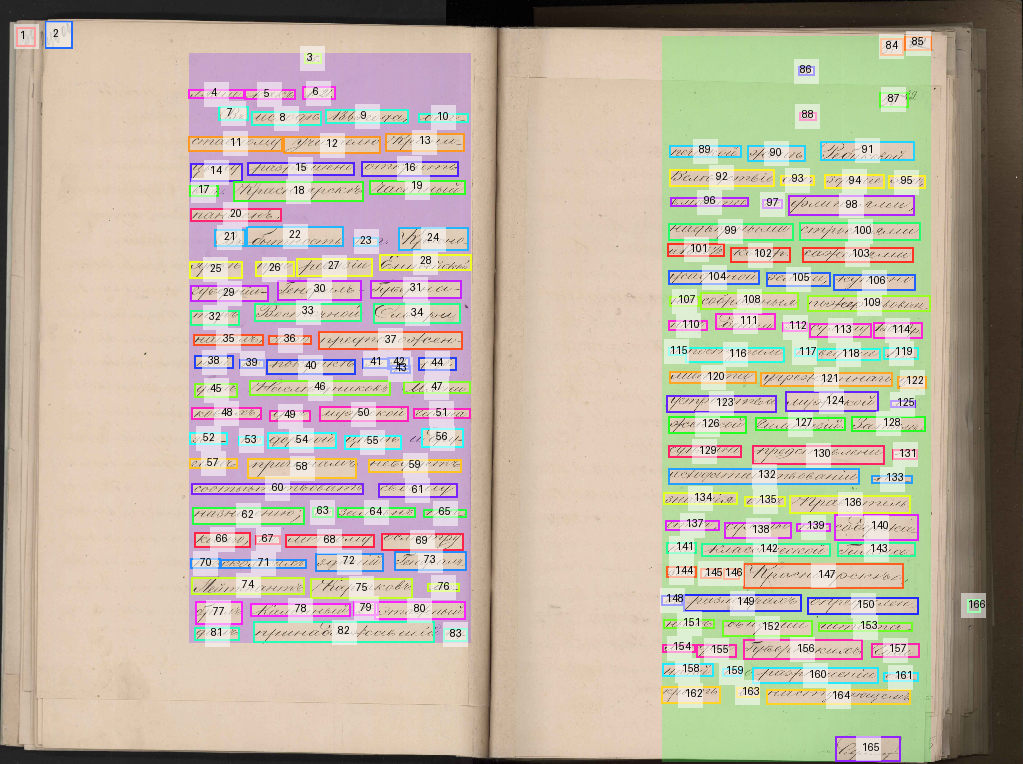

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

from manuscript import Pipeline
from manuscript.utils.visualization import visualize_page

# Прямая ссылка на файл из GitHub
image_url = "https://raw.githubusercontent.com/konstantinkozhin/manuscript-ocr/main/example/images/img1.jpeg"

# Куда сохранить локально
image_path = Path("img1.jpeg")

# Скачиваем пример, если файла еще нет
if not image_path.exists():
    urlretrieve(image_url, image_path)

trocr_recognizer = TrOCRRecognizer(
    model_name="taiga75/ru-trocr-1700s",
    device="cuda",
    batch_size=1,
)

# Создаем Pipeline с детектором по умолчанию (EAST) и TrOCR распознавателем
pipeline = Pipeline(
    recognizer=trocr_recognizer,
)

# Запуск пайплайна
result = pipeline.predict(str(image_path))

# Получение текста
text = pipeline.get_text(result["page"])
print("=" * 50)
print("Распознанный текст:")
print("=" * 50)
print(text)

# Визуализация результата
visualize_page(str(image_path), result["page"], show_lines=False, show_numbers=True, max_size=1024)


Следует учитывать, что качество распознавания в данном примере определяется не встроенными средствами `manuscript-ocr`, а внешней моделью `taiga75/ru-trocr-1700s`, подключенной к `Pipeline`. Соответственно, итоговое качество распознавания зависит прежде всего от выбранной модели TrOCR и ее характеристик, а не от самой библиотеки `manuscript-ocr`.

Таким образом, `manuscript-ocr` может использоваться совместно с другими решениями распознавания без значительных доработок и может быть встроен в интеграционные сценарии с внешними моделями.